# 👥 RFM Segmentation Analysis
## Brazilian E-Commerce — Olist Dataset
**Author:** Nayla 

## 1. Import Library & Load Cleaned Data

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/olist_clean.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
print(f"Data loaded: {df.shape}")

Data loaded: (110197, 20)


## 2. RFM Calculation
Menghitung tiga metrik utama untuk setiap pelanggan:
- **Recency (R):** Seberapa baru pelanggan melakukan transaksi
- **Frequency (F):** Seberapa sering pelanggan berbelanja
- **Monetary (M):** Seberapa besar total nilai belanja pelanggan

In [7]:
snapshot_date = df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', 
             lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum')
).reset_index()

print(rfm.describe().round(2))

        Recency  Frequency   Monetary
count  93358.00   93358.00   93358.00
mean     237.94       1.03     211.83
std      152.59       0.21     642.16
min        1.00       1.00       0.00
25%      114.00       1.00      63.76
50%      219.00       1.00     112.95
75%      346.00       1.00     201.74
max      714.00      15.00  109312.64


## 3. RFM Scoring & Segmentation
Memberikan skor 1–5 pada setiap dimensi RFM dan mengelompokkan pelanggan ke dalam 6 segmen bisnis.

| Segmen | Karakteristik |
|---|---|
| Champions | Beli baru, sering, nilai besar |
| Loyal Customers | Sering beli, nilai sedang |
| Potential Loyalists | Recency & frequency sedang |
| New Customers | Baru pertama beli |
| At Risk | Dulu aktif, sudah lama tidak beli |
| Lost Customers | Sudah sangat lama tidak aktif |

In [3]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 
                          5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

def segment(row):
    r, f = int(row['R_score']), int(row['F_score'])
    if r >= 4 and f >= 4: return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal Customers'
    elif r >= 4 and f <= 2: return 'New Customers'
    elif r <= 2 and f >= 3: return 'At Risk'
    elif r <= 2 and f <= 2: return 'Lost Customers'
    else: return 'Potential Loyalists'

rfm['Segment'] = rfm.apply(segment, axis=1)
print(rfm['Segment'].value_counts())

Segment
At Risk                22230
Loyal Customers        18824
Lost Customers         14986
New Customers          14984
Champions              14961
Potential Loyalists     7373
Name: count, dtype: int64


## 4. Visualisasi Segmen Pelanggan
Distribusi segmen pelanggan dan perbandingan rata-rata nilai belanja antar segmen.

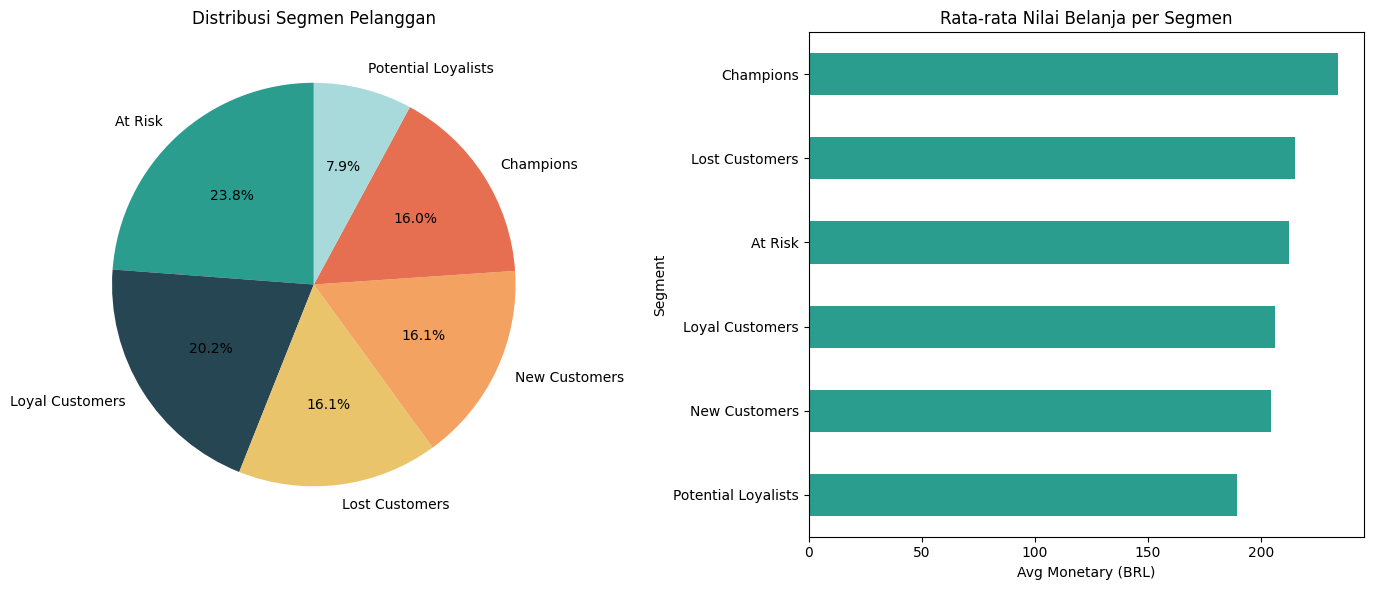

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2a9d8f','#264653','#e9c46a','#f4a261','#e76f51','#a8dadc']

seg_counts = rfm['Segment'].value_counts()
axes[0].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Distribusi Segmen Pelanggan')

seg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values()
seg_monetary.plot(kind='barh', ax=axes[1], color='#2a9d8f')
axes[1].set_title('Rata-rata Nilai Belanja per Segmen')
axes[1].set_xlabel('Avg Monetary (BRL)')

plt.tight_layout()
plt.savefig('../output/charts/04_rfm_segments.png', dpi=150)
plt.show()

## 5. Save RFM Result
Menyimpan hasil segmentasi untuk keperluan reporting dan rekomendasi strategi bisnis.

In [5]:
rfm.to_csv('../data/processed/rfm_result.csv', index=False)
print("RFM result tersimpan!")

RFM result tersimpan!


## 7. Business Insights & Recommendations

### Key Findings:
- Kategori **bed_bath_table** menyumbang revenue terbesar dibanding kategori lain
- Terjadi lonjakan penjualan signifikan pada **November 2017** yang kemungkinan besar dipicu oleh momen Black Friday
- Mayoritas pelanggan masuk segmen **New Customers** — artinya bisnis terus mendapat pelanggan baru namun retensi masih rendah

### Recommendations:
1. Fokuskan anggaran promosi pada kategori dengan revenue tertinggi
2. Siapkan kampanye khusus menjelang **Oktober–November** untuk memaksimalkan momen Black Friday
3. Buat **loyalty program** untuk segmen Champions & Loyal Customers agar tidak berpindah ke kompetitor
4. Lakukan **win-back campaign** via email/notifikasi untuk segmen At Risk sebelum mereka benar-benar hilang
5. Tingkatkan strategi **onboarding** untuk New Customers agar mendorong pembelian kedua